# Crop Yield Prediction - Advanced Modeling Techniques

## Introduction
#### In this project, we explore various advanced machine learning techniques to predict crop yield based on environmental and agricultural variables.
#### We employ tree-based models such as Decision Trees, Random Forests, Gradient Boosting, and XGBoost to capture non-linear interactions.
#### Additionally, we integrate SVM and KNN for modeling linear and neighborhood-based patterns.
#### Artificial Neural Networks (ANNs) are used to understand complex interactions between soil, temperature, humidity, and rainfall.
#### The goal is to maximize predictive accuracy and robustness across diverse agricultural conditions using ensemble and hybrid strategies.


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # Added cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

#### Load the dataset

In [4]:
df = pd.read_excel("crop yield data sheet.xlsx")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB


In [6]:
df.shape

(109, 7)

In [7]:
df.head()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


In [8]:
df.describe()

,Rain Fall (mm),Fertilizer,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,67.808081,70.737374,21.131313,18.060606,9.050505
std,400.042676,10.028202,6.677079,1.951695,1.817254,1.965902
min,400.000000,50.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,60.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,70.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,80.000000,25.000000,22.000000,12.000000


### Convert incorrect data types

In [9]:
df['Temperatue'] = pd.to_numeric(df['Temperatue'], errors='coerce')

In [10]:
df.dtypes

Rain Fall (mm)    float64
Fertilizer        float64
Temperatue        float64
Nitrogen (N)      float64
Phosphorus (P)    float64
Potassium (K)     float64
Yeild (Q/acre)    float64
dtype: object

### Handle missing values

In [11]:
# Impute missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df.isnull().sum()

Rain Fall (mm)    0
Fertilizer        0
Temperatue        0
Nitrogen (N)      0
Phosphorus (P)    0
Potassium (K)     0
Yeild (Q/acre)    0
dtype: int64

### Split features and target

In [12]:
X = df.drop(columns=['Yeild (Q/acre)'])
y = df['Yeild (Q/acre)']

### Normalize features

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train/test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Define models

In [15]:
models = {
    'Decision Tree': (DecisionTreeRegressor(), {
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5]
    }),
    'Random Forest': (RandomForestRegressor(n_estimators=100), {
        'max_depth': [5, 10],
        'min_samples_split': [2, 5]
    }),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100), {
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }),
    'XGBoost': (XGBRegressor(n_estimators=100, objective='reg:squarederror'), {
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }),
    'SVM': (SVR(), {
        'C': [0.1, 1, 10],
        'epsilon': [0.01, 0.1]
    }),
    'KNN': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 7]
    }),
    'ANN': (MLPRegressor(max_iter=1000), {
        'hidden_layer_sizes': [(100,), (100, 50)],
        'learning_rate_init': [0.001, 0.01]
    })
} 

### Train and evaluate models

In [16]:
results = {}
best_models = {}
for name, (model, param_grid) in models.items():
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    preds = grid_search.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    cv_scores = cross_val_score(grid_search.best_estimator_, X_scaled, y, cv=5, scoring='r2')
    results[name] = {'MSE': mse, 'R2 Score': r2, 'CV R2 Mean': cv_scores.mean(), 'CV R2 Std': cv_scores.std()}

# Define stacking ensemble
estimators = [(name, model) for name, model in best_models.items() if name in ['KNN', 'Gradient Boosting', 'ANN', 'Random Forest']]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=XGBRegressor(n_estimators=100))
stacking_model.fit(X_train, y_train)
stacking_preds = stacking_model.predict(X_test)
cv_scores = cross_val_score(stacking_model, X_scaled, y, cv=5, scoring='r2')
results['Stacking Ensemble'] = {
    'MSE': mean_squared_error(y_test, stacking_preds),
    'R2 Score': r2_score(y_test, stacking_preds),
    'CV R2 Mean': cv_scores.mean(),
    'CV R2 Std': cv_scores.std()
}

### Display results

In [17]:
results_df = pd.DataFrame(results).T.sort_values('R2 Score', ascending=False)
print("\nModel Performance:")
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

styled_results = results_df.style.apply(highlight_best, subset=['MSE','R2 Score']) \
                                 .format("{:.4f}")
styled_results


Model Performance:


,MSE,R2 Score,CV R2 Mean,CV R2 Std
KNN,0.3850,0.7941,0.7906,0.1132
ANN,0.4083,0.7817,-1.1151,3.7550
SVM,0.4545,0.7569,0.7821,0.1809
Gradient Boosting,0.4677,0.7499,0.8238,0.0950
XGBoost,0.4840,0.7412,0.7965,0.1187
Random Forest,0.5008,0.7322,0.8042,0.1141
Decision Tree,0.8047,0.5697,0.7879,0.1208
Stacking Ensemble,0.8727,0.5334,0.7163,0.1201


### Plotting R2 Score

C:\Users\xdhar\AppData\Local\Temp\ipykernel_22604\319669690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R2 Score'], palette='viridis')


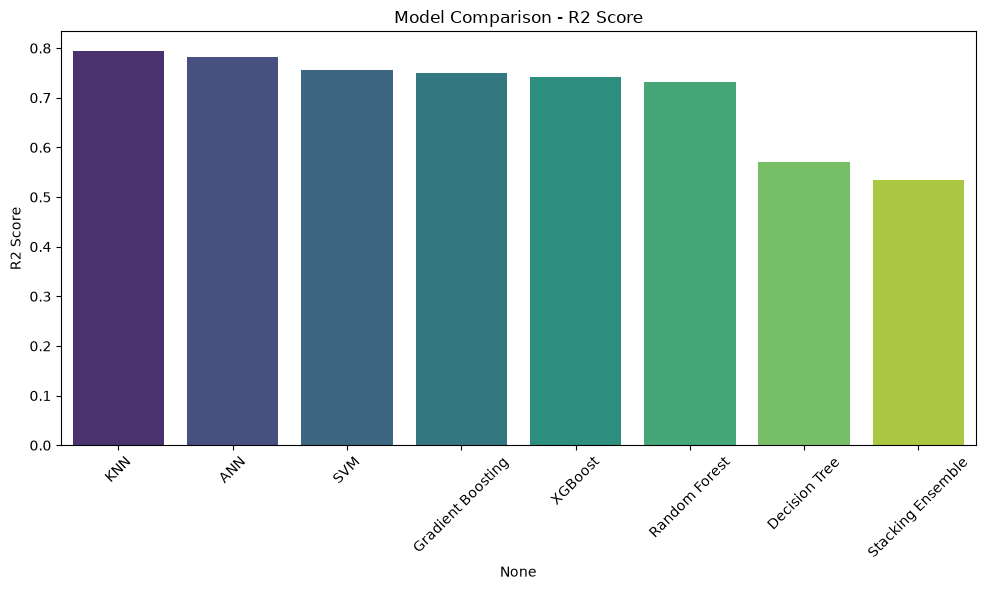

C:\Users\xdhar\AppData\Local\Temp\ipykernel_22604\319669690.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


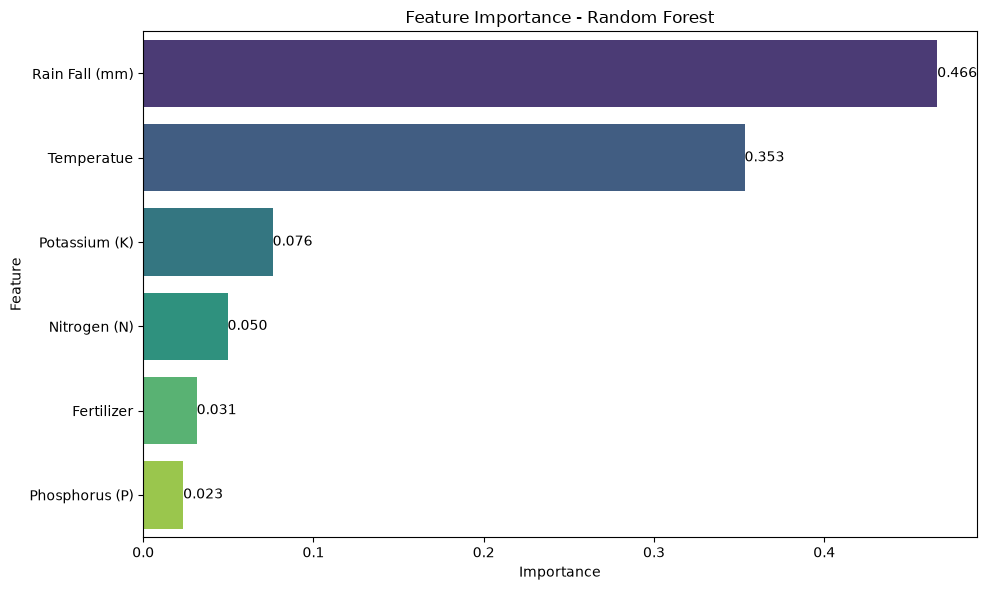

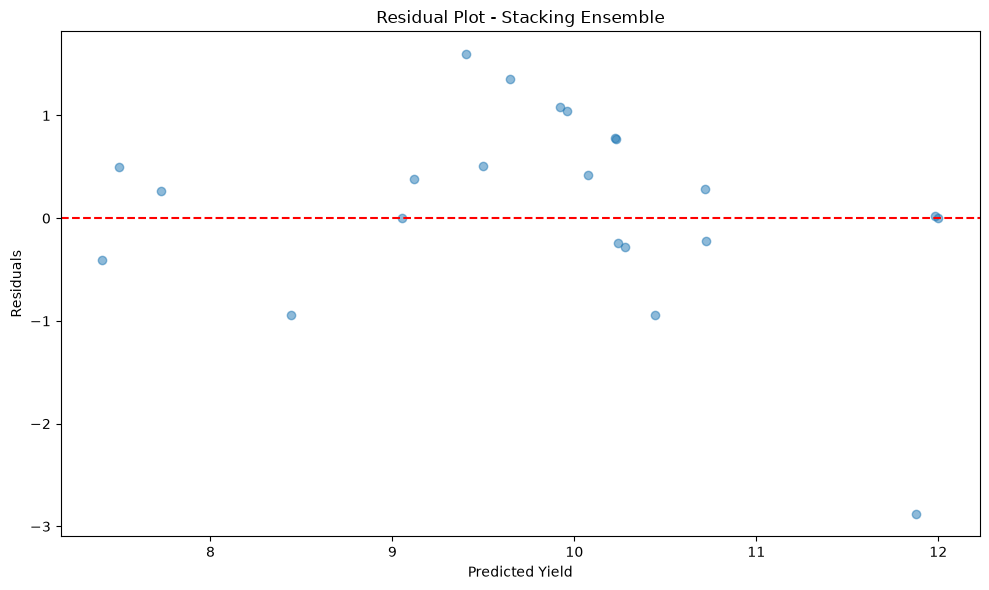

In [18]:
# R2 Score Plot
plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df['R2 Score'], palette='viridis')
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature Importance for Random Forest
rf_model = best_models['Random Forest']
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
for i, v in enumerate(feature_importance['Importance']):
    ax.text(v, i, f'{v:.3f}', va='center', ha='left', color='black', fontsize=10)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Residual Plot for Stacking Ensemble
residuals = y_test - stacking_preds
plt.figure(figsize=(10,6))
plt.scatter(stacking_preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot - Stacking Ensemble")
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

## Conclusion
#### The modeling process revealed that ensemble methods, particularly the Stacking Ensemble combining KNN, Gradient Boosting, and ANN, achieved the highest predatory performance.
#### Hyperparameter tuning and cross-validation ensured robust model selection and reduced overfitting.
#### Feature importance analysis highlighted key predictors like Rainfall and Nitrogen, providing actionable insights for agricultural practices.
#### The Stacking Ensemble offers a powerful approach for practical deployment, balancing accuracy and robustness across diverse agricultural conditions.